In [1]:
using NNlib
using PyCall
using IterativeSolvers
using LinearMaps
using BenchmarkTools
using TimerOutputs
using StaticArrays
using Profile
using ProfileSVG
using Plots
using LsqFit
using Printf
np=pyimport("numpy")

const base_length = [16,16,16]

const DataType = Float64

Float64

In [2]:
function apply_stencil(u; diag = 1)
    i, j, k = size(u)
    result = zeros(DataType, size(u))
    result[2:end-1, 2:end-1, 2:end-1] .= (
        .+ 6 .* u[2:end-1, 2:end-1, 2:end-1]
        .- u[3:end, 2:end-1, 2:end-1] .- u[1:end-2, 2:end-1, 2:end-1]
        .- u[2:end-1, 3:end, 2:end-1] .- u[2:end-1, 1:end-2, 2:end-1]
        .- u[2:end-1, 2:end-1, 3:end] .- u[2:end-1, 2:end-1, 1:end-2]
        
    ) / diag
    return result
end

function subtract_apply_stencil(result, u, rhs; diag)
    n, m, p = size(u)

    @inbounds Threads.@threads for k = 2:p-1
        @inbounds for j=2:m-1
            @simd for i=2:n-1
                result[i, j, k] = rhs[i,j,k] - (
                    6*u[i, j, k]
                    -u[i+1, j, k]-u[i-1, j, k]
                    -u[i, j+1, k]-u[i, j-1, k]
                    -u[i, j, k+1]-u[i, j, k-1]
                ) / diag
            end
        end
    end
end


function compute_res(u, rhs, diag)
    #print("The factor diag in compute res is: ", diag)
    temp = apply_stencil(u; diag = diag) .- rhs
    return sqrt(sum(temp .* temp)) / sqrt(sum(rhs .* rhs))
end

function compute_res(temp, u, rhs, diag)
 n, m, p = size(u)
 app_result = Threads.Atomic{DataType}(0)
 Threads.@threads for k = 2:p-1
        cum = 0
        @inbounds for j=2:m-1
            @simd for i=2:n-1
                a = rhs[i,j,k] - (
                    6*u[i, j, k]
                    -u[i+1, j, k]-u[i-1, j, k]
                    -u[i, j+1, k]-u[i, j-1, k]
                    -u[i, j, k+1]-u[i, j, k-1]
                ) / diag
                
                cum += a*a
            end
        end
        Threads.atomic_add!(app_result, cum)
    end

 rhs_result = Threads.Atomic{DataType}(0)
 Threads.@threads for k = 2:p-1
        b = 0  
        @inbounds for j=2:m-1
            @simd for i=2:n-1
                b += rhs[i, j, k]*rhs[i, j, k]
            end
        end
        Threads.atomic_add!(rhs_result, b)
    end


    return sqrt(app_result[]) / sqrt(rhs_result[])
end


function rb_gauss_seidel_3d(u::Array{DataType, 3}, f::Array{DataType, 3}; diag::Real =1, iterations::Int=3)
    #print("The factor diag in rb_gauss_seidel_3d is: ", diag)
    n, m, p = size(u)
    for _ = 1:iterations
        # Red update: (i + j + k) % 2 == 0
           Threads.@threads for k = 2:p-1
            for j = 2: m - 1 
                 @simd for i = 2:n - 1
                    if (i + j + k) % 2 == 1
                        u[i, j, k] = (1/6) * (
                            u[i+1, j, k] + u[i-1, j, k] +
                            u[i, j+1, k] + u[i, j-1, k] +
                            u[i, j, k+1] + u[i, j, k-1] +
                            diag * f[i, j, k]
                        )

                    end
                end
            end
        end
           # Black update: (i + j + k) % 2 == 1
         Threads.@threads for k=2:p-1
             for j=2:m-1
               @simd for i=2:n - 1
                    if (i + j + k) % 2 == 0
                        u[i, j, k] =  (1/6) * (
                            u[i+1, j, k] + u[i-1, j, k] +
                            u[i, j+1, k] + u[i, j-1, k] +
                            u[i, j, k+1] + u[i, j, k-1] +
                            diag * f[i, j, k]
                        )
                    end
                end
           end
        end
    end
        
end


function restrict(res)
    return res[1:2:end, 1:2:end, 1:2:end]
end

function prolong(coarse)
    i, j, k = size(coarse)
    temp = reshape(coarse, (size(coarse)..., 1, 1))
    temp2 = upsample_trilinear(temp; size=(2*i-1, 2*j-1, 2*k-1))
    return reshape(temp2, (2*i-1, 2*j-1, 2*k-1))
end



function prolong_helper(array, indices_un::NTuple{N, Int},
         res::MVector{N, Int},  
         dim::Int=1) where {N}
    if dim == N+1
        return array[(div.(res, 2) .+ 1)...]
    end

    i = indices_un[dim]
    res[dim] = i

    if isodd(i)
        return prolong_helper(array, indices_un, res, dim + 1)
    else
        res[dim] = i - 1
        val1 = prolong_helper(array, indices_un, res, dim + 1)

        res[dim] = i + 1
        val2 = prolong_helper(array, indices_un, res, dim + 1)

        return (val1 + val2) / 2
    end
end



function prolong_in_place_add(dest, source)
    m, n, p = size(dest)
    @inbounds Threads.@threads for k = 1:p-1
        @inbounds for j = 1:n-1
            @simd for i = 1:m-1
                sv = MVector{3, Int}((0,0,0))
                dest[i,j,k] += prolong_helper(source, (i, j, k), sv)
            end
        end
    end
end

prolong_in_place_add (generic function with 1 method)

In [3]:
function analytic_u(x, y, z)
    return -4*x^2-3*y^2+7*z^2
end



function set_boundary_conditions(u)
    i, j, k = size(u)
    for x =1:i
        for y = 1:j
            u[x, y, end]=analytic_u((x-1)/(i-1), (y-1)/(j-1), 1)
            u[x, y, 1] = analytic_u((x-1)/(i-1), (y-1)/(j-1), 0)
        end
    end

    for x =1:i
        for z =1:k
            u[x, end, z] = analytic_u((x-1)/(i-1), 1, (z-1)/(k-1))
            u[x, 1, z] = analytic_u((x-1)/(i-1), 0, (z-1)/(k-1))
        end 
    end

    for y = 1:j
        for z = 1:k
            u[end, y, z] = analytic_u(1, (y-1)/(j-1), (z-1)/(k-1))
            u[1, y, z] = analytic_u(0, (y-1)/(j-1), (z-1)/(k-1))
        end
    end
end

function matvec_shape(x_flat, shape, x_grid; factor=2)
    #x_grid = zeros(Float64,shape[1]+2, shape[2]+2, shape[3]+2)
    x_grid[2:end-1, 2:end-1, 2:end-1] = reshape(x_flat, shape)
    Ax_grid = apply_stencil(x_grid) ./ factor
    return vec(Ax_grid[2:end-1, 2:end-1, 2:end-1])
end

matvec_shape (generic function with 1 method)

In [4]:

function multigrid_V_cycle(base_length; num_iters=[1 , 1], num_smooth = 2, num_levels = nothing, level_num = nothing, rhs = nothing)

    if (num_levels===nothing || level_num===nothing)
        num_levels=level_num=size(num_iters)[1]
    end

    if(size(num_iters)[1] == 1)
        num_iters = [num_iters[1] for i = 1:num_levels]
    end
    
    length_by_level = [2^n .* base_length .+ 1 for n=1:level_num + 1]

    #Allocating working array
    guess = zeros(DataType, length_by_level[level_num]...)
    u = zeros(DataType, length_by_level[level_num]...)

    #if in uppermost level, set up the problem
    if rhs === nothing       
        #setting boundary conditions       
        set_boundary_conditions(u)
        #print(u)
        #Allocating right hand side
        rhs = -apply_stencil(u)
    end



    #getting matvec function and linear operator
    if level_num == 1
        
         x_grid = zeros(DataType, length_by_level[1]...)
         linear_function = x_flat -> matvec_shape(x_flat, Tuple(length_by_level[1] .- 2), x_grid; factor = 2^(num_levels-level_num))
         n = (2*base_length[1]-1)*(2*base_length[2]-1)*(2*base_length[3]-1)
         A = FunctionMap{Float64,false}(linear_function, n, n);
         unravel_c = reshape(rhs[2:end-1, 2:end-1, 2:end-1], :)
         #solving #coarse_grid
         sol = cg(A, unravel_c)
         #print (sol)
         sol_shaped = reshape(sol, Tuple(2 .* base_length .- 1))
         rhs[2:end-1, 2:end-1, 2:end-1] = sol_shaped
         return rhs
    end




    #Now doing the multigrid operation
    temp_res = num_levels==level_num ? zeros(DataType, size(u)) : nothing
    defect_domain=zeros(DataType, size(rhs)...)
    residuals = zeros(DataType, num_iters[1])
    
    for i = 1:num_iters[1]
        begin
        if level_num==num_levels
            
            residuum = compute_res(temp_res, guess, rhs, 2^(num_levels-level_num))
            println("After ", i, " iterations the residual is ", residuum)
            residuals[i]=residuum
        end

        #print("The current level is: ", level_num)
        rb_gauss_seidel_3d(guess, rhs; diag = 2^(num_levels-level_num), iterations = num_smooth)
        #print("The guess after the rb_guass_seidel is: ")
        #print(guess)
        #print("The right hand side for the ")
        #print("The guess after a ", 2, " Gauss-Seidel iteration is: ")
        #print(guess)
        #coarsening
        subtract_apply_stencil(defect_domain, guess, rhs; diag = 2^(num_levels-level_num))
        #print("The defect domain before coarsening is: ")
        #print(defect_domain)
        coarse = restrict(defect_domain)
        coarse = multigrid_V_cycle(base_length; num_iters=num_iters[2:end] ,num_smooth=num_smooth ,num_levels = num_levels, 
        level_num = level_num-1, rhs = coarse)

        #refining
       
        #refinemend = prolong(coarse)

        #print("The refined coarse grid solution: ")
        #print(refinemend)

        #Adding correction
        #print (refinemend.shape)
        #@timeit to "app guess" guess[2:end-1, 2:end-1, 2:end-1] .+= prolong(coarse)[2:end-1, 2:end-1, 2:end-1]
        prolong_in_place_add(guess, coarse)

        #print("After adding the coarse grid correction the guess is:")
        #print(guess)
        
        #doing the post smoothing
        #print("Current level: ", level_num)
        rb_gauss_seidel_3d(guess, rhs; diag= 2^(num_levels-level_num), iterations= num_smooth)

        #print("After the post smoothing step the guess is:")
        #print(guess)
        end
    end
        
    
    guess .+= u


    return level_num==num_levels ? (guess, residuals) : guess
end

multigrid_V_cycle (generic function with 1 method)

After 1 iterations the residual is 1.0
After 2 iterations the residual is 0.05143209501914575
After 3 iterations the residual is 0.0016092105786509267
After 4 iterations the residual is 5.567192915052793e-5
After 5 iterations the residual is 1.938732844146878e-6
After 6 iterations the residual is 7.25366529896563e-8
After 7 iterations the residual is 2.658073950211023e-9
After 8 iterations the residual is 1.0757369321544708e-10
After 9 iterations the residual is 4.296778766173975e-12
After 10 iterations the residual is 1.970348219828827e-13
After 1 iterations the residual is 1.0
After 2 iterations the residual is 0.05706012386462116
After 3 iterations the residual is 0.0019116019765389456
After 4 iterations the residual is 6.542905629282714e-5
After 5 iterations the residual is 2.313975639429453e-6
After 6 iterations the residual is 8.3850554466005e-8
After 7 iterations the residual is 3.0578001096044185e-9
After 8 iterations the residual is 1.1708121049723146e-10
After 9 iterations th

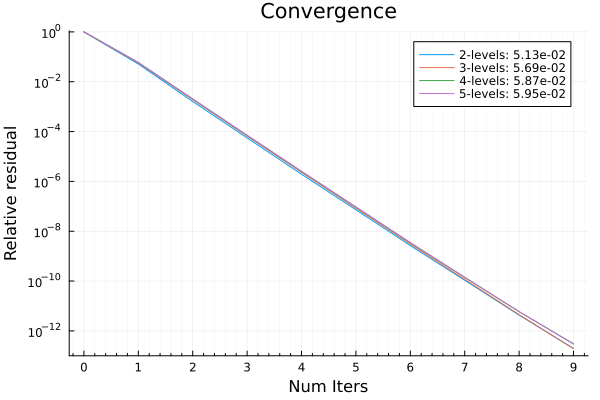

In [8]:
model(x, p) = p[1] .^ x
p0=[0.05]

x=range(0, 9, 10)

guess, residuals_mg = multigrid_V_cycle(base_length; num_iters=[10, 1]);
fit = curve_fit(model, x, residuals_mg, p0)
param=fit.param
label_string = @sprintf("2-levels: %4.2e", param[1])


p=plot(x, residuals_mg, yscale=:log10, label=label_string, minorgrid=true, 
    xticks = 0:1:10,
    yticks = [10.0^(-i) for i=0:2:14],
    ylim=(1e-13, 1.1))



#println("The fitting parameters are: ")
#println(param)



@time guess, residuals_mg =multigrid_V_cycle(base_length; num_iters=[10, 1, 1]);
fit = curve_fit(model, x, residuals_mg, p0)
param=fit.param
label_string = @sprintf("3-levels: %4.2e", param[1])
plot!(p, x, residuals_mg, yscale=:log10, label=label_string)

@time guess, residuals_mg =multigrid_V_cycle(base_length; num_iters=[10, 1, 1, 1]);
fit = curve_fit(model, x, residuals_mg, p0)
param=fit.param
label_string = @sprintf("4-levels: %4.2e", param[1])
plot!(p, x, residuals_mg, yscale=:log10, label=label_string)

@time guess, residuals_mg =multigrid_V_cycle(base_length; num_iters=[10, 1, 1, 1, 1]);
fit = curve_fit(model, x, residuals_mg, p0)
param=fit.param
label_string = @sprintf("5-levels: %4.2e", param[1])
plot!(p, x, residuals_mg, yscale=:log10, label=label_string)

title!(p,"Convergence")
xlabel!(p,"Num Iters")
ylabel!(p,"Relative residual")
savefig(p, "Residuals_plotted_asymmetric.pdf") 
p

In [15]:
#base_length = [16,16,16]
@time guess, residuals =multigrid_V_cycle(base_length; num_iters=[10, 1, 1]);

After 1 iterations the residual is 1.0
After 2 iterations the residual is 0.057455163
After 3 iterations the residual is 0.0019321089
After 4 iterations the residual is 6.633171e-5
After 5 iterations the residual is 2.6514085e-6
After 6 iterations the residual is 1.2651034e-6
After 7 iterations the residual is 1.2547191e-6
After 8 iterations the residual is 1.270062e-6
After 9 iterations the residual is 1.2609652e-6
After 10 iterations the residual is 1.2693778e-6
  2.386823 seconds (23.64 M allocations: 1.790 GiB, 27.10% gc time)


In [9]:
#base_length = [16,16,16]
to=TimerOutput()
@time multigrid_V_cycle(base_length; num_iters=[10, 1, 1, 1]);

  3.525579 seconds (191.43 M allocations: 7.929 GiB, 22.48% gc time)


In [10]:
@time multigrid_V_cycle(base_length; num_iters=[10, 1, 1, 1, 1]);

 36.681223 seconds (1.53 G allocations: 57.015 GiB, 21.07% gc time)


In [ ]:
@time guess, residuals = multigrid_V_cycle(base_length; num_iters=[10, 1, 1, 1, 1, 1]);